# Problem Statement
This project analyzes whether increasing product visibility (impressions) leads to higher sales. The goal is to identify high-performing products and simulate the impact of increased exposure on revenue.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("data.csv")
df.head()

,product_id,location,category,price,margin,impressions,clicks,orders,stock
0,P1,DE,premium,120,0.35,10000,800,120,150
1,P2,DE,mass,60,0.25,20000,1500,180,500
2,P3,DE,discount,30,0.15,30000,2000,150,800
3,P4,FR,premium,110,0.33,9000,700,100,120
4,P5,FR,mass,55,0.22,18000,1400,160,450


- Impressions → how many people see the product
- Clicks → how many people show interest
- Orders → how many people actually buy

In [3]:
df.shape

(50, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   50 non-null     object 
 1   location     50 non-null     object 
 2   category     50 non-null     object 
 3   price        50 non-null     int64  
 4   margin       50 non-null     float64
 5   impressions  50 non-null     int64  
 6   clicks       50 non-null     int64  
 7   orders       50 non-null     int64  
 8   stock        50 non-null     int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.6+ KB


In [5]:
df.describe()

,price,margin,impressions,clicks,orders,stock
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,64.240000,0.225600,17086.000000,1240.100000,132.100000,422.120000
std,36.689853,0.089492,7011.710613,456.037156,29.184319,239.264318
min,18.000000,0.080000,7000.000000,500.000000,80.000000,90.000000
25%,29.250000,0.142500,9650.000000,772.500000,115.750000,136.250000
50%,57.500000,0.225000,16650.000000,1265.000000,130.000000,415.000000
75%,100.750000,0.300000,20950.000000,1542.500000,149.500000,607.500000
max,135.000000,0.390000,32000.000000,2100.000000,200.000000,850.000000


**CTR (Click Through Rate)**

Measures attractiveness of product


**CVR (Conversion Rate)**

Measures how many buyers come from clicks

In [6]:
df["ctr"] = np.where(df["impressions"]>0, df["clicks"] / df["impressions"], 0)
df["cvr"] = np.where(df["clicks"]>0, df["orders"] / df["clicks"], 0)
df.head()

,product_id,location,category,price,margin,impressions,clicks,orders,stock,ctr,cvr
0,P1,DE,premium,120,0.35,10000,800,120,150,0.080000,0.150000
1,P2,DE,mass,60,0.25,20000,1500,180,500,0.075000,0.120000
2,P3,DE,discount,30,0.15,30000,2000,150,800,0.066667,0.075000
3,P4,FR,premium,110,0.33,9000,700,100,120,0.077778,0.142857
4,P5,FR,mass,55,0.22,18000,1400,160,450,0.077778,0.114286


In [7]:
df.replace([np.inf,-np.inf],0,inplace = True)
df.fillna(0,inplace=True)

In [8]:
print(df.isnull().sum())
df.describe()

product_id     0
location       0
category       0
price          0
margin         0
impressions    0
clicks         0
orders         0
stock          0
ctr            0
cvr            0
dtype: int64


,price,margin,impressions,clicks,orders,stock,ctr,cvr
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,64.240000,0.225600,17086.000000,1240.100000,132.100000,422.120000,0.073748,0.115727
std,36.689853,0.089492,7011.710613,456.037156,29.184319,239.264318,0.003764,0.028152
min,18.000000,0.080000,7000.000000,500.000000,80.000000,90.000000,0.065625,0.075000
25%,29.250000,0.142500,9650.000000,772.500000,115.750000,136.250000,0.071223,0.082844
50%,57.500000,0.225000,16650.000000,1265.000000,130.000000,415.000000,0.074359,0.117644
75%,100.750000,0.300000,20950.000000,1542.500000,149.500000,607.500000,0.076124,0.146029
max,135.000000,0.390000,32000.000000,2100.000000,200.000000,850.000000,0.080208,0.160000


In [9]:
df["revenue"] = df["orders"]*df["price"]
df["profit"] = df["revenue"]* df["margin"]
df.head()

,product_id,location,category,price,margin,impressions,clicks,orders,stock,ctr,cvr,revenue,profit
0,P1,DE,premium,120,0.35,10000,800,120,150,0.080000,0.150000,14400,5040.0
1,P2,DE,mass,60,0.25,20000,1500,180,500,0.075000,0.120000,10800,2700.0
2,P3,DE,discount,30,0.15,30000,2000,150,800,0.066667,0.075000,4500,675.0
3,P4,FR,premium,110,0.33,9000,700,100,120,0.077778,0.142857,11000,3630.0
4,P5,FR,mass,55,0.22,18000,1400,160,450,0.077778,0.114286,8800,1936.0


In [10]:
# product having high conversion
df.sort_values(by = "cvr",ascending=False).head(10)

,product_id,location,category,price,margin,impressions,clicks,orders,stock,ctr,cvr,revenue,profit
9,P10,DE,premium,130,0.38,7000,500,80,90,0.071429,0.160000,10400,3952.00
29,P30,DE,premium,135,0.39,7200,520,82,95,0.072222,0.157692,11070,4317.30
38,P39,DE,premium,128,0.37,9600,770,118,135,0.080208,0.153247,15104,5588.48
17,P18,ES,premium,105,0.31,8200,620,95,110,0.075610,0.153226,9975,3092.25
26,P27,ES,premium,98,0.29,7800,580,88,95,0.074359,0.151724,8624,2500.96
44,P45,ES,premium,101,0.30,8100,615,93,108,0.075926,0.151220,9393,2817.90
35,P36,ES,premium,102,0.30,8000,610,92,105,0.076250,0.150820,9384,2815.20
0,P1,DE,premium,120,0.35,10000,800,120,150,0.080000,0.150000,14400,5040.00
6,P7,ES,premium,100,0.30,8000,600,90,100,0.075000,0.150000,9000,2700.00
32,P33,FR,premium,118,0.35,9200,730,108,125,0.079348,0.147945,12744,4460.40


In [11]:
low_impression_threshold = df["impressions"].quantile(0.25)
high_cvr_threshold = df["cvr"].quantile(0.75)
print(low_impression_threshold)
print(high_cvr_threshold)

9650.0
0.14602941176470588


In [12]:
# product with low impression but good performance 
filtered_df = df[(df["impressions"]<low_impression_threshold) & (df["cvr"]>high_cvr_threshold)]
filtered_df

,product_id,location,category,price,margin,impressions,clicks,orders,stock,ctr,cvr,revenue,profit
6,P7,ES,premium,100,0.30,8000,600,90,100,0.075000,0.150000,9000,2700.00
9,P10,DE,premium,130,0.38,7000,500,80,90,0.071429,0.160000,10400,3952.00
14,P15,FR,premium,115,0.34,9500,750,110,130,0.078947,0.146667,12650,4301.00
17,P18,ES,premium,105,0.31,8200,620,95,110,0.075610,0.153226,9975,3092.25
26,P27,ES,premium,98,0.29,7800,580,88,95,0.074359,0.151724,8624,2500.96
29,P30,DE,premium,135,0.39,7200,520,82,95,0.072222,0.157692,11070,4317.30
32,P33,FR,premium,118,0.35,9200,730,108,125,0.079348,0.147945,12744,4460.40
35,P36,ES,premium,102,0.30,8000,610,92,105,0.076250,0.150820,9384,2815.20
38,P39,DE,premium,128,0.37,9600,770,118,135,0.080208,0.153247,15104,5588.48
41,P42,FR,premium,113,0.33,8900,690,102,118,0.077528,0.147826,11526,3803.58


In [13]:
# Category that perform best
df.groupby("category")[["ctr","cvr"]].mean()

,ctr,cvr
category,,
discount,0.069393,0.080185
mass,0.074987,0.118349
premium,0.076824,0.150318


In [14]:
# category - level revenue analysis
df.groupby("category")[["revenue","profit"]].sum()

,revenue,profit
category,,
discount,55310,6959.15
mass,171947,40328.32
premium,170621,57706.39


Although the mass category drives the highest revenue, the premium category is more valuable for the business as it generates the highest profit. Therefore, prioritizing premium products in visibility strategies would likely maximize overall profitability.

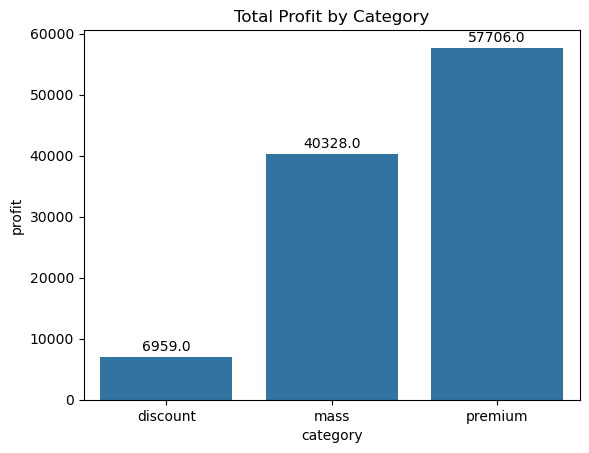

In [15]:
profit_data = df.groupby("category")["profit"].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="category", y="profit", data=profit_data)
plt.title("Total Profit by Category")
for i, row in profit_data.iterrows():
    plt.text(i, row["profit"] + 1000, round(row["profit"], 0), ha='center')
plt.show()

The premium category generates the highest total profit by a significant margin, indicating that focusing on premium products will maximize business profitability. Discount products contribute very little to profit and may not justify high visibility.

In [16]:
# location wise revenue
df.groupby(["location","category"])[["revenue","profit"]].sum()

revenue    profit
location category                   
DE       discount    23773   3524.60
         mass        72300  18710.70
         premium     65349  24072.78
ES       discount    14712   1409.10
         mass        40366   8152.02
         premium     46376  13926.31
FR       discount    16825   2025.45
         mass        59281  13465.60
         premium     58896  19707.30

Premium category consistently generates the highest profit across all locations (DE, FR, ES), with Germany contributing the highest share. This indicates a strong global preference for premium products, with Germany being the most profitable market.

**Checking Relationship Between Visibility and Sales**

In [17]:
correlation = df["impressions"].corr(df["orders"])
print("Correlation:", round(correlation, 3))

Correlation: 0.695


A correlation of 0.695 indicates a moderate positive relationship between impressions and orders, meaning higher visibility generally leads to more sales, but other factors also influence purchasing behavior.

# Simulation

**Assumptions**
- CTR and conversion rate remain constant when impressions change
- Customer behavior remains consistent across scenarios
- No external factors (seasonality, pricing changes) affect demand


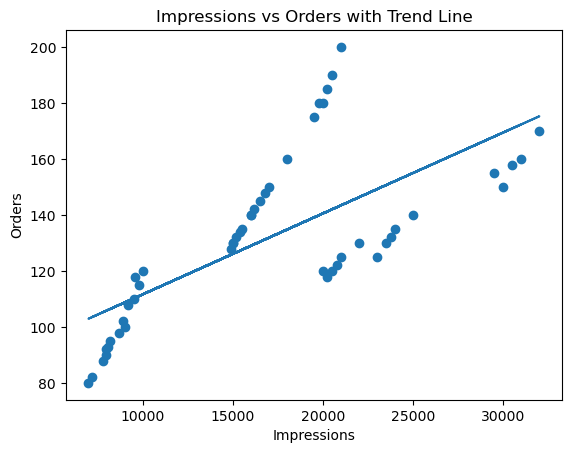

In [18]:
z = np.polyfit(df["impressions"], df["orders"], 1)
p = np.poly1d(z)

plt.scatter(df["impressions"], df["orders"])
plt.plot(df["impressions"], p(df["impressions"]))

plt.xlabel("Impressions")
plt.ylabel("Orders")
plt.title("Impressions vs Orders with Trend Line")
plt.show()

The graph shows a positive but not perfectly linear relationship between impressions and orders, indicating that while visibility drives sales, other factors like conversion rate and product quality play a significant role

In [19]:
df["new_impressions"] = df["impressions"] * 1.2
df["expected_clicks"] = df["new_impressions"] * df["ctr"]
df["demand"] = df["expected_clicks"] * df["cvr"]
df["expected_orders"] = df[["demand", "stock"]].min(axis=1)
df["expected_revenue"] = df["expected_orders"] * df["price"]


In [20]:
original_revenue = df["revenue"].sum()
expected_revenue = df["expected_revenue"].sum()

increase_percent = ((expected_revenue - original_revenue) / original_revenue) * 100

print("Original Revenue:", round(original_revenue, 2))
print("Expected Revenue:", round(expected_revenue, 2))
print("Increase %:", round(increase_percent, 2), "%")

Original Revenue: 397878
Expected Revenue: 470635.4
Increase %: 18.29 %


The simulation indicates that a 18.29% increase in product visibility leads to a proportional ~19% increase in revenue under the assumption of constant CTR and conversion rate. This suggests that optimizing visibility allocation—especially for high-performing products—can directly impact revenue growth.

In [21]:
df["stock_needed"] = df["demand"] - df["stock"]
df["stock_needed"] = df["stock_needed"].clip(lower=0)
total_needed = df["stock_needed"].sum()
print("Total additional stock needed:", total_needed)
df[df["stock_needed"] > 0][["product_id", "stock", "demand", "stock_needed"]]

Total additional stock needed: 61.2


,product_id,stock,demand,stock_needed
6,P7,100,108.0,8.0
9,P10,90,96.0,6.0
14,P15,130,132.0,2.0
17,P18,110,114.0,4.0
23,P24,115,117.6,2.6
26,P27,95,105.6,10.6
29,P30,95,98.4,3.4
32,P33,125,129.6,4.6
35,P36,105,110.4,5.4
38,P39,135,141.6,6.6


I calculated the difference between predicted demand and available stock to estimate the additional inventory required. This helps identify stock shortages and quantify lost sales opportunities.

In [22]:
factors = [0.8, 1.0, 1.2, 1.5]

results = {}

for f in factors:
    
    new_impressions = df["impressions"] * f
    expected_clicks = new_impressions * df["ctr"]
    demand = expected_clicks * df["cvr"]
    final_orders = pd.concat([demand, df["stock"]], axis=1).min(axis=1)
    expected_revenue = (final_orders * df["price"]).sum()
    
    results[f] = expected_revenue

results

{0.8: np.float64(318302.4),
 1.0: np.float64(397878.0),
 1.2: np.float64(470635.4),
 1.5: np.float64(539782.5)}

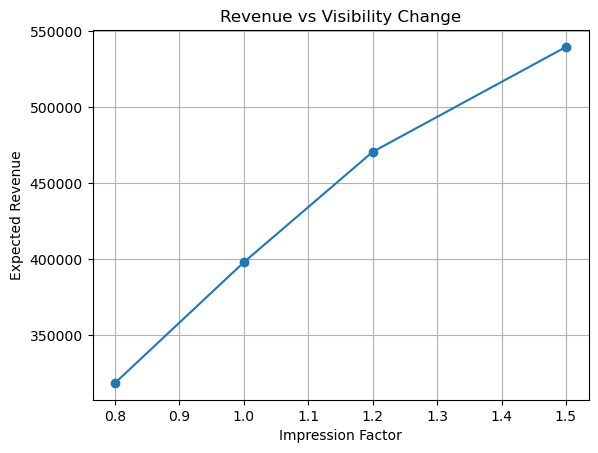

In [23]:
import matplotlib.pyplot as plt

factors = list(results.keys())
revenues = list(results.values())

plt.figure()
plt.plot(factors, revenues, marker='o')

plt.xlabel("Impression Factor")
plt.ylabel("Expected Revenue")
plt.title("Revenue vs Visibility Change")

plt.grid()

plt.show()

The graph shows that revenue increases with higher visibility; however, the growth is not perfectly linear. The slight flattening at higher impression factors indicates the impact of stock constraints, which limit the ability to fully convert increased demand into sales.

# Targeted Simulation: Low-Impression, High-Conversion Products

In [24]:
factors = [1.0, 1.2, 1.5]

results_filtered = {}

for f in factors:
    
    new_impressions = filtered_df["impressions"] * f
    expected_clicks = new_impressions * filtered_df["ctr"]
    demand = expected_clicks * filtered_df["cvr"]
    final_orders = pd.concat([demand, df["stock"]], axis=1).min(axis=1)
    
    expected_revenue = (final_orders * filtered_df["price"]).sum()
    
    results_filtered[f] = expected_revenue

results_filtered

{1.0: np.float64(119870.0),
 1.2: np.float64(137317.0),
 1.5: np.float64(137317.0)}

In [25]:
baseline = filtered_df["revenue"].sum()
print("Original Revenue (filtered products):", baseline)

Original Revenue (filtered products): 119870


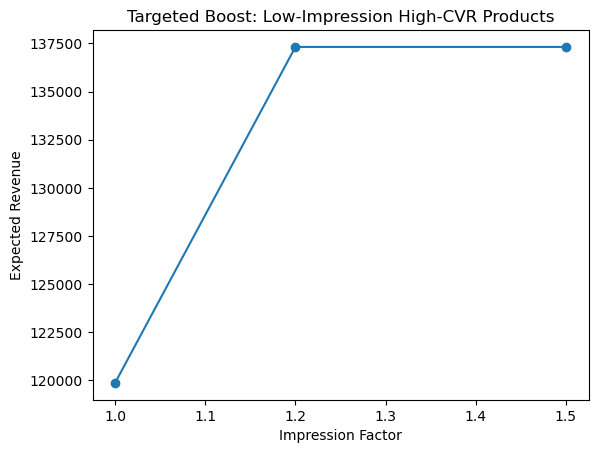

In [26]:
import matplotlib.pyplot as plt

plt.plot(list(results_filtered.keys()), list(results_filtered.values()), marker='o')
plt.xlabel("Impression Factor")
plt.ylabel("Expected Revenue")
plt.title("Targeted Boost: Low-Impression High-CVR Products")
plt.show()

The targeted simulation shows that increasing visibility of high-performing products initially leads to significant revenue growth. However, beyond a certain point, the revenue plateaus due to stock limitations, indicating that further increases in impressions do not translate into additional sales.

# Reduce Low-Performing Products

In [27]:
low_cvr = df["cvr"].quantile(0.25)
low_perf_df = df[df["cvr"] < low_cvr]
df["adjusted_impressions"] = df["impressions"]
df.loc[df["cvr"] < low_cvr, "adjusted_impressions"] *= 0.7

C:\Users\Dell\AppData\Local\Temp\ipykernel_16860\1272336955.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[21000. 17500. 15400. 22400. 16800. 21700. 16450. 14350. 20650. 16100.
 14560. 21350. 16660.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["cvr"] < low_cvr, "adjusted_impressions"] *= 0.7


In [28]:
new_impressions = df["adjusted_impressions"]
expected_clicks = new_impressions * df["ctr"]
demand = expected_clicks * df["cvr"]

final_orders = pd.concat([demand, df["stock"]], axis=1).min(axis=1)

expected_revenue_reduced = (final_orders * df["price"]).sum()

print("Revenue after reducing low-performing products:", expected_revenue_reduced)

Revenue after reducing low-performing products: 383466.0


In [29]:
original = df["revenue"].sum()

print("Original Revenue:", original)
print("After Reduction:", expected_revenue_reduced)
print("Change %:", ((expected_revenue_reduced - original) / original) * 100)

Original Revenue: 397878
After Reduction: 383466.0
Change %: -3.622215855111366


While reducing visibility of low-performing products results in a small decrease in total revenue, it improves overall efficiency by reallocating exposure away from low-conversion products. This strategy becomes more effective when combined with increasing visibility for high-performing products.

# Germany + Premium 

In [30]:
de_premium = df[
    (df["location"] == "DE") & 
    (df["category"] == "premium")
]
de_premium

,product_id,location,category,price,margin,impressions,clicks,orders,stock,ctr,cvr,revenue,profit,new_impressions,expected_clicks,demand,expected_orders,expected_revenue,stock_needed,adjusted_impressions
0,P1,DE,premium,120,0.35,10000,800,120,150,0.080000,0.150000,14400,5040.00,12000.0,960.0,144.0,144.0,17280.0,0.0,10000.0
9,P10,DE,premium,130,0.38,7000,500,80,90,0.071429,0.160000,10400,3952.00,8400.0,600.0,96.0,90.0,11700.0,6.0,7000.0
20,P21,DE,premium,125,0.36,9800,780,115,140,0.079592,0.147436,14375,5175.00,11760.0,936.0,138.0,138.0,17250.0,0.0,9800.0
29,P30,DE,premium,135,0.39,7200,520,82,95,0.072222,0.157692,11070,4317.30,8640.0,624.0,98.4,95.0,12825.0,3.4,7200.0
38,P39,DE,premium,128,0.37,9600,770,118,135,0.080208,0.153247,15104,5588.48,11520.0,924.0,141.6,135.0,17280.0,6.6,9600.0


In [31]:
df["new_impressions_gp"] = df["impressions"]

df.loc[
    (df["location"] == "DE") & 
    (df["category"] == "premium"),
    "new_impressions_gp"
] *= 1.2

In [39]:
expected_clicks = df["new_impressions_gp"] * df["ctr"]
demand = expected_clicks * df["cvr"]

final_orders = pd.concat([demand, filtered_df["stock"]], axis=1).min(axis=1)

expected_revenue_gp = (final_orders * df["price"]).sum()

In [40]:
original = df["revenue"].sum()

print("Original Revenue:", original)
print("After DE + Premium Boost:", expected_revenue_gp)
print("Change %:", ((expected_revenue_gp - original) / original) * 100)

Original Revenue: 397878
After DE + Premium Boost: 408864.0
Change %: 2.7611478895540844


Targeting premium products in Germany leads to a measurable increase in revenue, demonstrating that focusing on high-performing segments identified in the analysis can yield efficient and business-aligned improvements without unnecessary exposure increases.

# CONCLUSION

This analysis shows that increasing product visibility (impressions) can lead to higher revenue; however, the impact depends strongly on product performance and stock availability.

Premium products consistently generate the highest profit across all locations, especially in Germany, making them the most valuable segment for targeted promotion. Correlation analysis indicates a positive but not perfect relationship between impressions and orders, suggesting that visibility alone is not the sole driver of sales.

Simulation results demonstrate that increasing impressions leads to revenue growth, but the effect diminishes at higher levels due to stock constraints. Targeted simulations on low-impression, high-conversion products show that focusing on under-exposed high-performing products yields more efficient revenue gains compared to a uniform visibility increase.

Overall, the optimal strategy is to increase visibility selectively for high-performing products while ensuring sufficient stock availability. Aligning marketing efforts with inventory capacity is essential to maximize revenue and avoid missed sales opportunities.